## 1. Install & imports

In [ ]:
!pip install TorchCRF

In [ ]:
!pip install scikit-learn sklearn_crfsuite --quiet

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
from TorchCRF import CRF
from sklearn.metrics import classification_report
from sklearn_crfsuite import metrics as crf_metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)

PyTorch: 2.10.0+cu128
Device: cuda


## 2. Load the BIEXS dataset

In [ ]:
def read_biexs_file(filepath):
    """Parse dataset_biexs.txt into a list of sentences.
    Each sentence is a list of (char, tag) tuples.
    """
    sentences, tokens, tags = [], [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.rsplit(' ', 1)
                if len(parts) == 2:
                    tokens.append(parts[0])
                    tags.append(parts[1])
            else:
                if tokens:
                    sentences.append(list(zip(tokens, tags)))
                    tokens, tags = [], []
    if tokens:
        sentences.append(list(zip(tokens, tags)))
    return sentences

sentences = read_biexs_file('/content/dataset_biexs.txt')
print(f'Total sentences : {len(sentences):,}')
print(f'Example sentence: {sentences[0][:8]} ...')

Total sentences : 8,649
Example sentence: [('د', 'B'), ('و', 'E'), ('ت', 'B'), ('ہ', 'I'), ('ا', 'I'), ('ی', 'I'), ('ی', 'E'), ('ک', 'B')] ...


## 3. Build vocabularies & encode data

In [ ]:
# ── Tag vocabulary ──────────────────────────────────────────────────────────
TAG2IDX = {'B': 0, 'I': 1, 'E': 2, 'X': 3, 'S': 4}
IDX2TAG = {v: k for k, v in TAG2IDX.items()}
NUM_TAGS = len(TAG2IDX)

# ── Character vocabulary ─────────────────────────────────────────────────────
# 0 = PAD (reserved),  1 = UNK (unseen characters at inference time)
all_chars = {ch for sent in sentences for ch, _ in sent}
CHAR2IDX  = {ch: idx + 2 for idx, ch in enumerate(sorted(all_chars))}
CHAR2IDX['<PAD>'] = 0
CHAR2IDX['<UNK>'] = 1
VOCAB_SIZE = len(CHAR2IDX)

print(f'Vocabulary size : {VOCAB_SIZE:,} unique characters')
print(f'Tag set         : {TAG2IDX}')

# ── Encode ───────────────────────────────────────────────────────────────────
X_raw = [[CHAR2IDX.get(ch, 1) for ch, _ in sent] for sent in sentences]
y_raw = [[TAG2IDX[tag]         for _, tag in sent] for sent in sentences]

# Sequence length: 95th percentile keeps coverage high while reducing padding waste
MAX_LEN = int(np.percentile([len(s) for s in X_raw], 95))
print(f'MAX_LEN (95th pct): {MAX_LEN}')

def pad_seq(sequences, maxlen, pad_value=0):
    """Post-pad / truncate a list of integer sequences to maxlen."""
    result = np.full((len(sequences), maxlen), pad_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        trunc = seq[:maxlen]
        result[i, :len(trunc)] = trunc
    return result

X_pad = pad_seq(X_raw, MAX_LEN, pad_value=0)
y_pad = pad_seq(y_raw, MAX_LEN, pad_value=-1)   # -1 marks padding positions

print(f'X shape: {X_pad.shape}  |  y shape: {y_pad.shape}')

Vocabulary size : 106 unique characters
Tag set         : {'B': 0, 'I': 1, 'E': 2, 'X': 3, 'S': 4}
MAX_LEN (95th pct): 203
X shape: (8649, 203)  |  y shape: (8649, 203)


## 4. Train / test split  (80 / 20)

In [ ]:
split = int(0.8 * len(X_pad))

X_train, X_test = X_pad[:split], X_pad[split:]
y_train, y_test = y_pad[:split], y_pad[split:]
y_test_raw      = y_raw[split:]   # keep original (unpadded) for evaluation

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 6,919  |  Test: 1,730


## 5. Dataset & Bi-LSTM-CRF model

In [ ]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class UrduDataset(Dataset):
    """Wraps padded X / y arrays.
    CRF requires non-negative tag indices, so padding (-1) is replaced with 0.
    A uint8 mask tracks which positions are real vs. padded (TorchCRF requires uint8).
    """
    def __init__(self, X, y):
        self.X    = torch.tensor(X, dtype=torch.long)
        self.y    = torch.tensor(np.where(y == -1, 0, y), dtype=torch.long)
        self.mask = torch.tensor(y != -1, dtype=torch.uint8)  # TorchCRF needs uint8, not bool

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.mask[idx]


# ── Bi-LSTM + CRF model ───────────────────────────────────────────────────────
class BiLSTMCRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, lstm_units, num_tags, dropout=0.3):
        super().__init__()
        # Embedding: padding_idx=0 keeps PAD vectors zeroed & unfrozen
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Two stacked Bi-LSTMs with dropout between them
        self.bilstm1 = nn.LSTM(embed_dim,      lstm_units,      batch_first=True, bidirectional=True)
        self.drop1   = nn.Dropout(dropout)
        self.bilstm2 = nn.LSTM(lstm_units * 2, lstm_units // 2, batch_first=True, bidirectional=True)
        self.drop2   = nn.Dropout(dropout)

        # Linear projection to tag space (no activation — CRF scores raw logits)
        self.hidden2tag = nn.Linear(lstm_units, num_tags)

        # CRF output layer — TorchCRF takes only num_tags, no batch_first arg
        self.crf = CRF(num_tags)

    def _emissions(self, x):
        """Forward pass up to (but not including) the CRF."""
        emb    = self.embedding(x)       # (B, T, E)
        out, _ = self.bilstm1(emb)       # (B, T, 2*H)
        out    = self.drop1(out)
        out, _ = self.bilstm2(out)       # (B, T, H)
        out    = self.drop2(out)
        return self.hidden2tag(out)      # (B, T, num_tags)

    def loss(self, x, y, mask):
        """CRF negative log-likelihood (averaged over batch).
        TorchCRF.forward() returns a per-sample tensor — negate and mean manually.
        """
        return -self.crf.forward(self._emissions(x), y, mask).mean()

    def decode(self, x, mask):
        """Viterbi decoding — returns list-of-lists of tag indices.
        TorchCRF uses viterbi_decode(), not decode().
        """
        return self.crf.viterbi_decode(self._emissions(x), mask)


EMBED_DIM  = 64
LSTM_UNITS = 128
DROPOUT    = 0.3

model = BiLSTMCRF(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, NUM_TAGS, DROPOUT).to(device)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

BiLSTMCRF(
  (embedding): Embedding(106, 64, padding_idx=0)
  (bilstm1): LSTM(64, 128, batch_first=True, bidirectional=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (bilstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (hidden2tag): Linear(in_features=128, out_features=5, bias=True)
  (crf): CRF()
)
Total parameters: 370,984


## 6. Train the Bi-LSTM

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

BATCH_SIZE = 96
EPOCHS     = 30
PATIENCE   = 4

# ── Data loaders ─────────────────────────────────────────────────────────────
full_ds   = UrduDataset(X_train, y_train)
val_n     = int(0.1 * len(full_ds))
train_n   = len(full_ds) - val_n
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_n, val_n])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

# ── Optimizer & scheduler ────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                               patience=2, min_lr=1e-5)

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
best_val_loss    = float('inf')
patience_counter = 0
best_state       = None

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    t_loss = t_correct = t_tokens = 0

    for X_b, y_b, m_b in train_loader:
        X_b, y_b, m_b = X_b.to(device), y_b.to(device), m_b.to(device)
        optimizer.zero_grad()
        loss = model.loss(X_b, y_b, m_b)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * X_b.size(0)

        # Token-level accuracy (no grad needed)
        with torch.no_grad():
            for i, seq in enumerate(model.decode(X_b, m_b)):
                true = y_b[i][m_b[i].bool()].cpu().numpy()  # .bool() for tensor indexing
                pred = np.array(seq[:len(true)])
                t_correct += (pred == true).sum()
                t_tokens  += len(true)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    v_loss = v_correct = v_tokens = 0

    with torch.no_grad():
        for X_b, y_b, m_b in val_loader:
            X_b, y_b, m_b = X_b.to(device), y_b.to(device), m_b.to(device)
            v_loss += model.loss(X_b, y_b, m_b).item() * X_b.size(0)
            for i, seq in enumerate(model.decode(X_b, m_b)):
                true = y_b[i][m_b[i].bool()].cpu().numpy()  # .bool() for tensor indexing
                pred = np.array(seq[:len(true)])
                v_correct += (pred == true).sum()
                v_tokens  += len(true)

    tl = t_loss / train_n;  ta = t_correct / t_tokens
    vl = v_loss / val_n;    va = v_correct / v_tokens

    history['loss'].append(tl);        history['accuracy'].append(float(ta))
    history['val_loss'].append(vl);    history['val_accuracy'].append(float(va))

    print(f'Epoch {epoch+1:2d}/{EPOCHS}  '
          f'loss: {tl:.4f}  acc: {ta:.4f}  '
          f'val_loss: {vl:.4f}  val_acc: {va:.4f}')

    scheduler.step(vl)

    if vl < best_val_loss:
        best_val_loss    = vl
        best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Restore best weights
model.load_state_dict(best_state)
model.to(device)
torch.save(model.state_dict(), 'urdu_segmentor_bilstm.pt')
print('Model saved to urdu_segmentor_bilstm.pt')

Epoch  1/30  loss: 85.4592  acc: 0.5673  val_loss: 55.4181  val_acc: 0.7388
Epoch  2/30  loss: 43.2717  acc: 0.8041  val_loss: 32.7801  val_acc: 0.8558
Epoch  3/30  loss: 29.4447  acc: 0.8728  val_loss: 25.2369  val_acc: 0.8934
Epoch  4/30  loss: 23.6915  acc: 0.8996  val_loss: 21.5248  val_acc: 0.9079
Epoch  5/30  loss: 20.4501  acc: 0.9133  val_loss: 19.4394  val_acc: 0.9176
Epoch  6/30  loss: 18.2145  acc: 0.9236  val_loss: 17.5150  val_acc: 0.9257
Epoch  7/30  loss: 16.5291  acc: 0.9305  val_loss: 16.5168  val_acc: 0.9296
Epoch  8/30  loss: 15.1222  acc: 0.9361  val_loss: 15.3013  val_acc: 0.9340
Epoch  9/30  loss: 13.9091  acc: 0.9413  val_loss: 14.7125  val_acc: 0.9368
Epoch 10/30  loss: 12.9450  acc: 0.9449  val_loss: 14.1737  val_acc: 0.9376
Epoch 11/30  loss: 12.0757  acc: 0.9481  val_loss: 13.6096  val_acc: 0.9404
Epoch 12/30  loss: 11.2982  acc: 0.9508  val_loss: 13.3248  val_acc: 0.9406
Epoch 13/30  loss: 10.6922  acc: 0.9536  val_loss: 13.0502  val_acc: 0.9425
Epoch 14/30 

## 7. Training curves

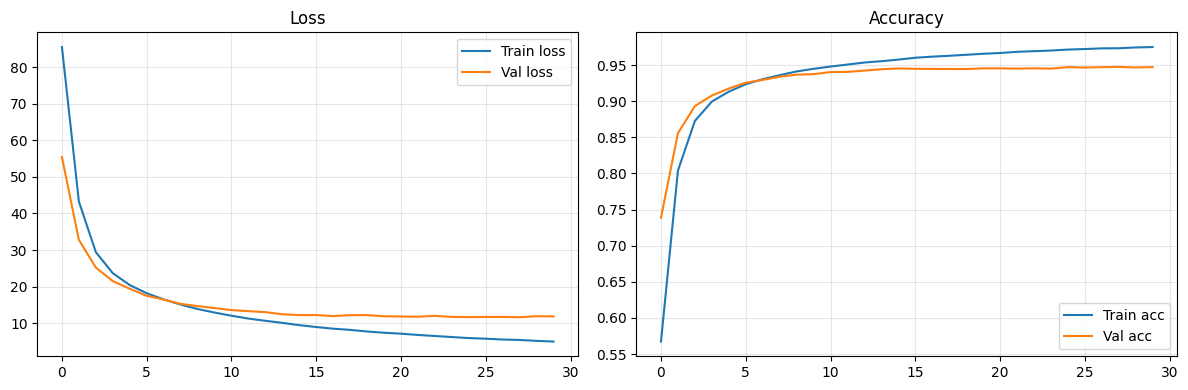

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'],     label='Train loss')
axes[0].plot(history['val_loss'], label='Val loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['accuracy'],     label='Train acc')
axes[1].plot(history['val_accuracy'], label='Val acc')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluate the Bi-LSTM

In [ ]:
def decode_predictions(X_pad_batch, y_raw_batch, model, idx2tag, device, batch_size=256):
    """Run model on padded input; strip padding using original lengths."""
    model.eval()
    all_preds   = []
    X_tensor    = torch.tensor(X_pad_batch, dtype=torch.long)
    mask_tensor = torch.tensor(X_pad_batch != 0, dtype=torch.bool)

    with torch.no_grad():
        for i in range(0, len(X_pad_batch), batch_size):
            X_b = X_tensor[i:i+batch_size].to(device)
            m_b = mask_tensor[i:i+batch_size].to(device)
            all_preds.extend(model.decode(X_b, m_b))

    y_true_flat, y_pred_flat = [], []
    for i, true_seq_original in enumerate(y_raw_batch):
        L           = len(true_seq_original)
        effective_L = min(L, MAX_LEN)
        y_true_flat.extend([idx2tag[t] for t in true_seq_original[:effective_L]])
        y_pred_flat.extend([idx2tag[p] for p in all_preds[i][:effective_L]])
    return y_true_flat, y_pred_flat


y_true_lstm, y_pred_lstm = decode_predictions(X_test, y_test_raw, model, IDX2TAG, device)

print('\n── Bi-LSTM Classification Report ──')
print(classification_report(y_true_lstm, y_pred_lstm,
                             labels=['B','I','E','S','X'], digits=3))


── Bi-LSTM Classification Report ──
              precision    recall  f1-score   support

           B      0.934     0.963     0.949     46414
           I      0.959     0.920     0.939     73033
           E      0.926     0.955     0.940     46373
           S      0.185     0.252     0.213       456
           X      0.000     0.000     0.000         0

    accuracy                          0.940    166276
   macro avg      0.601     0.618     0.608    166276
weighted avg      0.941     0.940     0.940    166276



## 9. CRF baseline (unchanged — sklearn_crfsuite)

In [ ]:
# ── Reuse the same feature extraction from FYP_3 ────────────────────────────
non_joiners  = ['ا','د','ڈ','ذ','ر','ڑ','ز','ژ','و','آ']
punctuations = ['،','۔','.','،','!','?',':',';','؟']

def char2features(sent, i):
    char = sent[i][0]
    features = {
        'bias': 1.0,
        'char': char,
        'char.is_non_joiner': char in non_joiners,
        'char.is_digit': char.isdigit(),
        'char.is_punctuation': char in punctuations,
        'char.is_space': char.isspace(),
        'char.is_alpha': char.isalpha(),
    }
    if i > 0:
        p = sent[i-1][0]
        features.update({'-1:char': p,
                          '-1:char.is_non_joiner': p in non_joiners,
                          '-1:char.is_digit': p.isdigit(),
                          '-1:char.is_punctuation': p in punctuations,
                          '-1:bigram': p + char})
    else:
        features['BOS'] = True
    if i < len(sent)-1:
        n = sent[i+1][0]
        features.update({'+1:char': n,
                          '+1:char.is_non_joiner': n in non_joiners,
                          '+1:char.is_digit': n.isdigit(),
                          '+1:char.is_punctuation': n in punctuations,
                          '+1:bigram': char + n})
    else:
        features['EOS'] = True
    if i > 1:           features['-2:char'] = sent[i-2][0]
    if i < len(sent)-2: features['+2:char'] = sent[i+2][0]
    return features

def sent2features(sent): return [char2features(sent, i) for i in range(len(sent))]
def sent2labels(sent):   return [tag for _, tag in sent]

# ── Use same 80/20 split ─────────────────────────────────────────────────────
test_sents  = sentences[split:]
X_crf_test  = [sent2features(s) for s in test_sents]
y_crf_test  = [sent2labels(s)   for s in test_sents]

crf = joblib.load('/content/urdu_segmentor_crf.pkl')
y_crf_pred  = crf.predict(X_crf_test)

# Flatten for sklearn report
y_true_crf  = [t for seq in y_crf_test  for t in seq]
y_pred_crf  = [t for seq in y_crf_pred  for t in seq]

print('\n── CRF Classification Report ──')
print(classification_report(y_true_crf, y_pred_crf,
                             labels=['B','I','E','S','X'], digits=3))


── CRF Classification Report ──
              precision    recall  f1-score   support

           B      0.879     0.904     0.892     46531
           I      0.900     0.865     0.882     73397
           E      0.871     0.896     0.884     46531
           S      0.188     0.265     0.220       456
           X      0.000     0.000     0.000         0

    accuracy                          0.883    166915
   macro avg      0.568     0.586     0.576    166915
weighted avg      0.884     0.883     0.884    166915



## 10. Side-by-side comparison table

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

tags = ['B', 'I', 'E', 'S', 'X']

def build_report(y_true, y_pred, model_name):
    rows = []
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=tags, zero_division=0)
    for i, tag in enumerate(tags):
        rows.append({'Model': model_name, 'Tag': tag,
                     'Precision': round(p[i], 3),
                     'Recall':    round(r[i], 3),
                     'F1':        round(f[i], 3),
                     'Support':   int(s[i])})
    acc = accuracy_score(y_true, y_pred)
    rows.append({'Model': model_name, 'Tag': 'OVERALL',
                 'Precision': '—', 'Recall': '—',
                 'F1': '—', 'Support': round(acc, 4)})
    return rows

rows = build_report(y_true_crf,  y_pred_crf,  'CRF') + \
       build_report(y_true_lstm, y_pred_lstm, 'Bi-LSTM')

df = pd.DataFrame(rows)
comparison = df.pivot_table(index='Tag',
                             columns='Model',
                             values=['Precision','Recall','F1'],
                             aggfunc='first')
comparison.columns = [f'{m} {stat}' for stat, m in comparison.columns]
comparison = comparison[sorted(comparison.columns)]
print(comparison.to_string())

        Bi-LSTM F1 Bi-LSTM Precision Bi-LSTM Recall CRF F1 CRF Precision CRF Recall
Tag                                                                                
B            0.949             0.934          0.963  0.892         0.879      0.904
E             0.94             0.926          0.955  0.884         0.871      0.896
I            0.939             0.959           0.92  0.882           0.9      0.865
OVERALL          —                 —              —      —             —          —
S            0.213             0.185          0.252   0.22         0.188      0.265
X              0.0               0.0            0.0    0.0           0.0        0.0


## 11. F1 bar chart — CRF vs Bi-LSTM

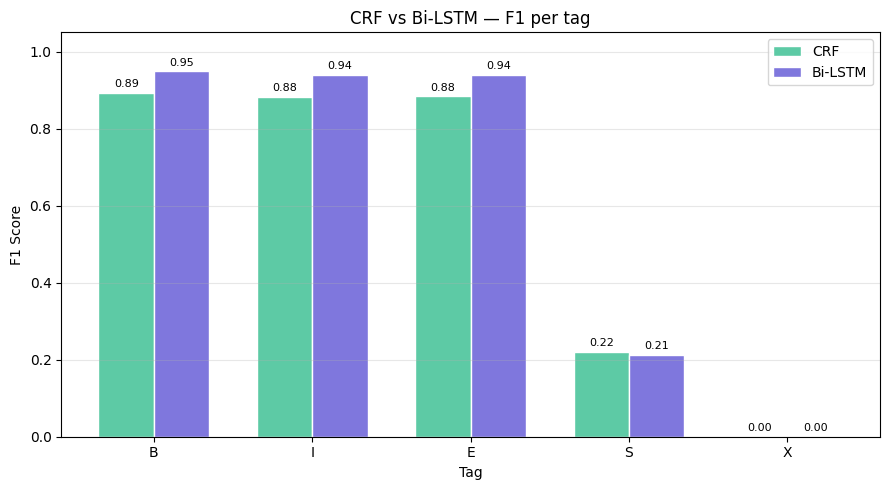


Overall accuracy  —  CRF: 0.8832  |  Bi-LSTM: 0.9398


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

tags_plot = ['B', 'I', 'E', 'S', 'X']
_, _, f1_crf,  _ = precision_recall_fscore_support(y_true_crf,  y_pred_crf,  labels=tags_plot, zero_division=0)
_, _, f1_lstm, _ = precision_recall_fscore_support(y_true_lstm, y_pred_lstm, labels=tags_plot, zero_division=0)

x     = np.arange(len(tags_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, f1_crf,  width, label='CRF',     color='#5DCAA5', edgecolor='white')
bars2 = ax.bar(x + width/2, f1_lstm, width, label='Bi-LSTM', color='#7F77DD', edgecolor='white')

ax.set_xlabel('Tag'); ax.set_ylabel('F1 Score')
ax.set_title('CRF vs Bi-LSTM — F1 per tag')
ax.set_xticks(x); ax.set_xticklabels(tags_plot)
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.01,
                           f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.01,
                           f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('crf_vs_bilstm_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOverall accuracy  —  CRF: {accuracy_score(y_true_crf, y_pred_crf):.4f}  '
      f'|  Bi-LSTM: {accuracy_score(y_true_lstm, y_pred_lstm):.4f}')

## 12. Demo — character-level prediction on a sentence

In [ ]:
import re

def clean_urdu_text(text):
    """Remove English letters, numbers, and non-Urdu symbols."""
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)   # URLs / mentions
    text = re.sub(r'[a-zA-Z0-9]', '', text)                  # English & digits
    text = re.sub(r'[^\u0600-\u06FF\s۔،؟!]', '', text)      # keep Urdu range
    text = text.replace('ي', 'ی').replace('ئ', 'ی')          # normalise yeh
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict_bilstm(text, model, char2idx, idx2tag, max_len, device):
    """Return list of (char, predicted_tag) for a raw Urdu string."""
    text      = clean_urdu_text(text)
    chars     = list(text)
    trunc_len = min(len(chars), max_len)
    encoded   = [char2idx.get(c, 1) for c in chars[:trunc_len]]
    padded    = encoded + [0] * (max_len - trunc_len)

    X_tensor = torch.tensor([padded], dtype=torch.long).to(device)
    mask     = torch.zeros(1, max_len, dtype=torch.bool).to(device)
    mask[0, :trunc_len] = True

    model.eval()
    with torch.no_grad():
        preds = model.decode(X_tensor, mask)

    return list(zip(chars[:trunc_len], [idx2tag[p] for p in preds[0]]))


def predict_crf(text, crf_model):
    """Return list of (char, predicted_tag) using the CRF."""
    text  = clean_urdu_text(text)
    sent  = [(ch, '?') for ch in text]
    feats = sent2features(sent)
    tags  = crf_model.predict_single(feats)
    return list(zip(text, tags))


# ── Run on a test sentence ───────────────────────────────────────────────────
test_sentence = "یہ دنیا ایک عجیب و غریب جگہ ہے جہاں ہر انسان اپنی زندگی کے سفر میں مختلف راستوں پر چلتا ہے، کبھی خوشی کے لمحات اسے آسمان کی بلندیوں تک لے جاتے ہیں اور کبھی غم کی گہرائیاں اسے زمین کی تہوں میں دھکیل دیتی ہیں، مگر یہی نشیب و فراز ہی اصل میں زندگی کا حسن ہے اور انسان کو یہ سمجھنا چاہیے کہ ہر تکلیف کے بعد آرام ضرور آتا ہے اور ہر اندھیری رات کے بعد ایک روشن صبح طلوع ہوتی ہے۔"

lstm_out = predict_bilstm(test_sentence, model, CHAR2IDX, IDX2TAG, MAX_LEN, device)
crf_out  = predict_crf(test_sentence, crf)

print(f'Input: {test_sentence}\n')
print(f'{"Char":<6} {"CRF":>6} {"Bi-LSTM":>8}')
print('-' * 24)
for (ch, crf_tag), (_, lstm_tag) in zip(crf_out, lstm_out):
    display = '·' if ch == ' ' else ch
    match   = '' if crf_tag == lstm_tag else '  ← diff'
    print(f'{display:<6} {crf_tag:>6} {lstm_tag:>8}{match}')

Input: یہ دنیا ایک عجیب و غریب جگہ ہے جہاں ہر انسان اپنی زندگی کے سفر میں مختلف راستوں پر چلتا ہے، کبھی خوشی کے لمحات اسے آسمان کی بلندیوں تک لے جاتے ہیں اور کبھی غم کی گہرائیاں اسے زمین کی تہوں میں دھکیل دیتی ہیں، مگر یہی نشیب و فراز ہی اصل میں زندگی کا حسن ہے اور انسان کو یہ سمجھنا چاہیے کہ ہر تکلیف کے بعد آرام ضرور آتا ہے اور ہر اندھیری رات کے بعد ایک روشن صبح طلوع ہوتی ہے۔

Char      CRF  Bi-LSTM
------------------------
ی           B        B
ہ           I        I
·           E        E
د           B        B
ن           I        I
ی           E        I  ← diff
ا           B        I  ← diff
·           I        E  ← diff
ا           I        B  ← diff
ی           I        I
ک           E        E
·           B        B
ع           I        I
ج           I        I
ی           I        E  ← diff
ب           E        B  ← diff
·           B        E  ← diff
و           I        B  ← diff
·           E        E
غ           B        B
ر           I        I
ی           E        I  

## 13. Reconstruct words from tag sequences

In [ ]:
def biexs_to_words(char_tag_pairs):
    """Reconstruct words from (char, tag) output.
    B=begin, I=inside, E=end, S=single-char word, X=space (skip).
    """
    words, current = [], ''
    for ch, tag in char_tag_pairs:
        if tag == 'X':
            if current: words.append(current); current = ''
        elif tag == 'S':
            if current: words.append(current); current = ''
            words.append(ch)
        elif tag == 'B':
            if current: words.append(current)
            current = ch
        elif tag in ('I', 'E'):
            current += ch
            if tag == 'E': words.append(current); current = ''
    if current: words.append(current)
    return words


crf_words  = biexs_to_words(crf_out)
lstm_words = biexs_to_words(lstm_out)

print(f'Input        : {test_sentence}')
print(f'CRF words    : {crf_words}')
print(f'Bi-LSTM words: {lstm_words}')

Input        : یہ دنیا ایک عجیب و غریب جگہ ہے جہاں ہر انسان اپنی زندگی کے سفر میں مختلف راستوں پر چلتا ہے، کبھی خوشی کے لمحات اسے آسمان کی بلندیوں تک لے جاتے ہیں اور کبھی غم کی گہرائیاں اسے زمین کی تہوں میں دھکیل دیتی ہیں، مگر یہی نشیب و فراز ہی اصل میں زندگی کا حسن ہے اور انسان کو یہ سمجھنا چاہیے کہ ہر تکلیف کے بعد آرام ضرور آتا ہے اور ہر اندھیری رات کے بعد ایک روشن صبح طلوع ہوتی ہے۔
CRF words    : ['یہ ', 'دنی', 'ا ایک', ' عجیب', ' و ', 'غری', 'ب ', 'جگہ ', 'ہے', ' جہاں', ' ہر', ' ان', 'سان ', 'اپنی ', 'زندگی ', 'کے', ' سفر ', 'میں', ' مختلف', ' راستوں ', 'پر ', 'چلتا ', 'ہے،', ' ک', 'بھی ', 'خوشی ', 'کے', ' ل', 'محات ', 'اسے', ' آسمان ', 'کی', ' بلندیوں', ' ت', 'ک لے', ' جاتے', ' ہیں', ' اور', ' ک', 'بھی ', 'غم ', 'کی ', 'گہر', 'اییاں', ' اسے', ' زمین ', 'کی ت', 'ہوں', ' میں', ' دھ', 'کیل ', 'دیتی ', 'ہیں،', ' مگر ی', 'ہی', ' نشیب', ' و ', 'فراز ', 'ہی', ' اصل ', 'میں', ' زندگی ', 'کا ', 'حسن ', 'ہے', ' اور', ' ان', 'سان ', 'کو ', 'یہ', ' سمجھنا ', 'چاہیے', ' کہ', ' ہر ', 'تک', 'لیف